In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d

In [3]:
df = pd.read_csv('co2/Rae_2021_CO2_wSmooth.csv')

# Print the first few rows of the dataframe
print(df.head())

   site  age     pH  pH_16pc  pH_84pc  xco2  xco2_16pc  xco2_84pc  \
0  668B  3.6  8.187    8.172    8.202   271        254        289   
1  668B  3.6  8.181    8.166    8.196   277        259        295   
2  999A  3.9  8.139    8.123    8.154   290        270        311   
3  999A  4.6  8.150    8.135    8.165   279        260        299   
4  999A  5.0  8.130    8.115    8.145   298        278        320   

   xco2_alkalinityLow  xco2_alkalinityHigh  ref  xco2_smooth  
0                 250                  293  NaN          286  
1                 255                  299  NaN          286  
2                 265                  315  NaN          285  
3                 255                  303  NaN          283  
4                 273                  324  NaN          282  


In [4]:
kage=df['age']
age=kage/1000
co2=df['xco2_smooth']
co2_raw=df['xco2']

In [5]:
age_r = np.linspace(5, 65, 601)
#print(x_regular)

interpolator = interp1d(age, co2, kind='linear', fill_value='extrapolate')

co2_r = interpolator(age_r)

start_time=49.1
end_time=53.3

mask = (age_r >= start_time) & (age_r <= end_time)
#print(mask)
co2_rm=co2_r[mask]
age_rm=age_r[mask]
#print(co2_rm)
#print(age_rm)
co2_rma = np.mean(co2_rm)
print(co2_rma)
co2_deepmip = 1400

1462.0030578848039


In [2]:
# read in CenCO2PIP CO2

df1 = pd.read_csv('co2/CenoCO2-v1.2/SPATIAL-Lab-CenoCO2-5f95122/out/100kyrCO2.csv')

# Print the first few rows of the dataframe
print(df1.head())


    ages      2.5%       25%       50%       75%     97.5%
0  67.95  6.378846  6.688697  6.864046  7.059189  7.407533
1  67.85  6.387688  6.693063  6.862150  7.045182  7.379153
2  67.75  6.419768  6.696473  6.860957  7.040412  7.358510
3  67.65  6.427611  6.706847  6.858707  7.026932  7.340325
4  67.55  6.442405  6.710760  6.860502  7.017042  7.326070


In [7]:
cenage=df1['ages']
cenco2=df1['50%']
cenco2=np.exp(cenco2)
cenco2u=np.exp(df1['97.5%'])
cenco2l=np.exp(df1['2.5%'])
cenco275=np.exp(df1['75%'])
cenco225=np.exp(df1['25%'])

cenmask = (cenage >= start_time) & (cenage <= end_time)
cenco2_rm=cenco2[cenmask]
cenco275_rm=cenco275[cenmask]
cenco225_rm=cenco225[cenmask]
cenco2u_rm=cenco2u[cenmask]
cenco2l_rm=cenco2l[cenmask]
cenage_rm=cenage[cenmask]
#print(co2_rm)
print(age_rm)
cenco2_rma = np.mean(cenco2_rm)
cenco275_rma = np.mean(cenco275_rm)
cenco225_rma = np.mean(cenco225_rm)
cenco2u_rma = np.mean(cenco2u_rm)
cenco2l_rma = np.mean(cenco2l_rm)
print(cenco2_rma)
print(cenco2_rma/280.0)
print(cenco275_rma)
print(cenco275_rma/280.0)
print(cenco225_rma)
print(cenco225_rma/280.0)
print(cenco2u_rma)
print(cenco2u_rma/280.0)
print(cenco2l_rma)
print(cenco2l_rma/280.0)

[49.1 49.2 49.3 49.4 49.5 49.6 49.7 49.8 49.9 50.  50.1 50.2 50.3 50.4
 50.5 50.6 50.7 50.8 50.9 51.  51.1 51.2 51.3 51.4 51.5 51.6 51.7 51.8
 51.9 52.  52.1 52.2 52.3 52.4 52.5 52.6 52.7 52.8 52.9 53.  53.1 53.2]
1380.220420761318
4.929358645576136
1495.4146014325245
5.3407664336875875
1273.615378453056
4.548626351618058
1748.1435155981023
6.243369698564651
1089.9710142272002
3.8927536222400008


In [7]:
co2_p1=3.0*280.0

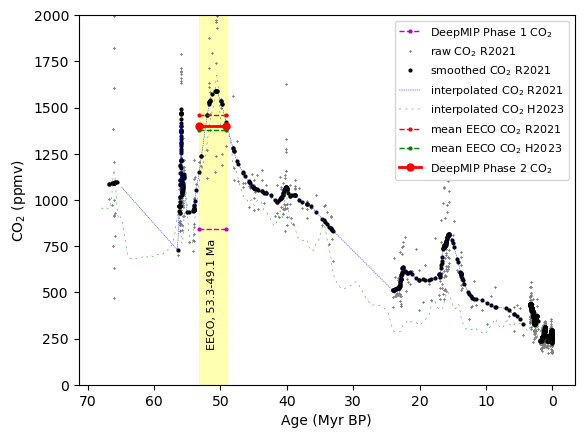

In [8]:
fig, ax = plt.subplots()

ax.plot([start_time, end_time], [co2_p1, co2_p1], 'mo--',linewidth=1,markersize=2,label='DeepMIP Phase 1 CO$_2$')
ax.plot(age, co2_raw, marker='x',markersize=1,color='grey',linestyle='',label='raw CO$_2$ R2021')  # 'o' adds markers to the plot
ax.plot(age, co2, marker='o',markersize=2,color='black',linestyle='',label='smoothed CO$_2$ R2021')  # 'o' adds markers to the plot
line, =ax.plot(age_r, co2_r, marker='',color='blue',linestyle='--',linewidth=0.3,label='interpolated CO$_2$ R2021')
line, =ax.plot(cenage, cenco2, marker='',color='green',linestyle='--',linewidth=0.3,label='interpolated CO$_2$ H2023')
ax.plot([start_time, end_time], [co2_rma, co2_rma], 'ro--',linewidth=1,markersize=2,label='mean EECO CO$_2$ R2021')
ax.plot([start_time, end_time], [cenco2_rma, cenco2_rma], 'go--',linewidth=1,markersize=2,label='mean EECO CO$_2$ H2023')
ax.plot([start_time, end_time], [co2_deepmip, co2_deepmip], 'ro-',linewidth=2,markersize=5,label='DeepMIP Phase 2 CO$_2$')


line.set_dashes([5, 10])


plt.gca().invert_xaxis()

# Add title and labels
#plt.title('CO$_2$ from Rae et al (2021)')
plt.xlabel('Age (Myr BP)')
plt.ylabel('CO$_2$ (ppmv)')

plt.axvspan(xmin=49.1, xmax=53.3, color='yellow', alpha=0.3)

plt.text(52, 200, 'EECO, 53.3-49.1 Ma', fontsize=8, color='black', rotation=90)

plt.legend(fontsize=8)

ax.set_ylim(0, 2000)

plt.savefig('co2_plot.pdf', format='pdf', bbox_inches='tight')


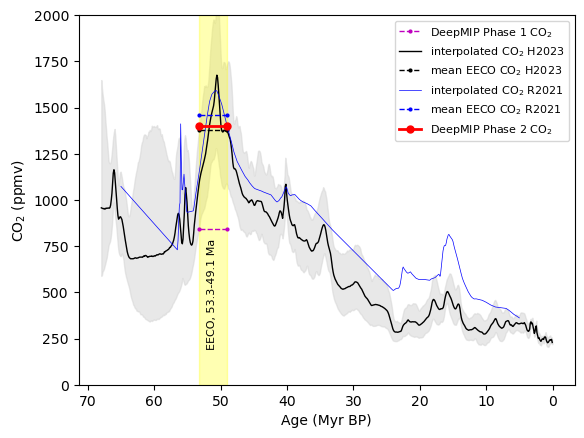

In [13]:
fig, ax = plt.subplots()

ax.plot([start_time, end_time], [co2_p1, co2_p1], 'mo--',linewidth=1,markersize=2,label='DeepMIP Phase 1 CO$_2$')

line, =ax.plot(cenage, cenco2, marker='',color='black',linestyle='-',linewidth=1,label='interpolated CO$_2$ H2023')
ax.plot([start_time, end_time], [cenco2_rma, cenco2_rma], 'ko--',linewidth=1,markersize=2,label='mean EECO CO$_2$ H2023')

line, =ax.plot(age_r, co2_r, marker='',color='blue',linestyle='-',linewidth=0.5,label='interpolated CO$_2$ R2021')
ax.plot([start_time, end_time], [co2_rma, co2_rma], 'bo--',linewidth=1,markersize=2,label='mean EECO CO$_2$ R2021')

ax.plot([start_time, end_time], [co2_deepmip, co2_deepmip], 'ro-',linewidth=2,markersize=5,label='DeepMIP Phase 2 CO$_2$')

ax.fill_between(cenage, cenco2l, cenco2u, color='lightgrey', alpha=0.5)


#line.set_dashes([5, 10])


plt.gca().invert_xaxis()

# Add title and labels
#plt.title('CO$_2$ from Rae et al (2021)')
plt.xlabel('Age (Myr BP)')
plt.ylabel('CO$_2$ (ppmv)')

plt.axvspan(xmin=49.1, xmax=53.3, color='yellow', alpha=0.3)

plt.text(52, 200, 'EECO, 53.3-49.1 Ma', fontsize=8, color='black', rotation=90)

plt.legend(fontsize=8)

ax.set_ylim(0, 2000)

plt.savefig('co2_plot_new.pdf', format='pdf', bbox_inches='tight')
